# Real-Data PJR Verification -- Exploratory Data Analysis

Basic EDA over the results of the real-data (n, T) grid experiment
(`real_data_tools/real_aaai_grid_experiment.py`) and its PJR verification
(`verification/verify_pjr.py` / `multiprocessing_verify_pjr.py`), across
every dataset in `real_data/json_datasets/`.

Reads directly from the bundled, checked-in results archive
(`aaai_experiments/real_data_grid_experiment_results.zip`) rather than a
live `experiments/` directory, so cloning the repo and running this
notebook reproduces the same analysis with no separate experiment/
verification run required. Everything below is read straight out of the
zip -- nothing is extracted to disk. Inside the archive, each dataset's
results sit under their own top-level folder (e.g.
`spotify-daily_tsoi/run_0/...`, `spotify-daily_tsoi/pjr_results.jsonl`),
mirroring the `experiments/<dataset name>/` layout exactly.

Mirrors `eda/pjr_eda.ipynb` (the synthetic-grid notebook) in structure,
but spans *multiple* datasets (one per real dataset) rather than a
single experiment directory, and adds a few real-data-specific checks: a
per-dataset breakdown (since "the grid" here is really 9-10 independent
datasets with very different characteristics), and a check of whether
the designated "first rounds" runs (`is_first_rounds`) behave any
differently from randomly-windowed runs.

Assumes this notebook is launched with the repository root as the
working directory (e.g. `task jupyter`, or `jupyter lab` run from the
repo root).

In [1]:
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Locate the archive

Jupyter sets the kernel's working directory to this notebook's own
folder (`src/eda/`), not the repo root -- so we find the repo root by
walking up for `pyproject.toml` rather than relying on a relative path.

In [2]:
def find_repo_root(marker: str = "pyproject.toml") -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' in any parent of {Path.cwd()}")


REPO_ROOT = find_repo_root()
ARCHIVE_PATH = REPO_ROOT / "aaai_experiments" / "real_data_grid_experiment_results.zip"

if not ARCHIVE_PATH.exists():
    raise FileNotFoundError(
        f"Results archive not found at {ARCHIVE_PATH} -- did you clone with the "
        "aaai_experiments/ directory intact?"
    )

print(f"Using archive: {ARCHIVE_PATH}")

Using archive: /home/tristan/repos/temporal_serial_dictator/aaai_experiments/real_data_grid_experiment_results.zip


## Load the data

Both tables are read directly out of the zip via `zipfile`, without
extracting anything to disk. The set of datasets is discovered from the
archive's own top-level folder names, rather than from
`real_data/json_datasets/`, so this notebook has no dependency on
anything outside the archive itself.

In [3]:
with zipfile.ZipFile(ARCHIVE_PATH) as archive:
    names = archive.namelist()
    dataset_names = sorted({n.split("/")[0] for n in names})

    results_frames = []
    violations_frames = []
    for name in dataset_names:
        with archive.open(f"{name}/pjr_results.jsonl") as f:
            results_frames.append(pd.read_json(f, lines=True))
        if f"{name}/all_violations.jsonl" in names:
            with archive.open(f"{name}/all_violations.jsonl") as f:
                violations_frames.append(pd.read_json(f, lines=True))

results_df = pd.concat(results_frames, ignore_index=True)
violations_df = pd.concat(violations_frames, ignore_index=True)

print(f"Datasets in archive: {len(dataset_names)}")
print(f"results_df:    {results_df.shape[0]:>7} rows (one per run)")
print(f"violations_df: {violations_df.shape[0]:>7} rows (one per violating group)")
results_df.head()

Datasets in archive: 10
results_df:        850 rows (one per run)
violations_df:  603469 rows (one per violating group)


,run,dataset,T,n,downsized,original_n,original_T,round_start,is_first_rounds,num_violations,satisfied,worst_gap,worst_group_size
0,run_0,eurovision_song_contest_tsoi,5,5,True,53,45,0,True,0,True,NaN,NaN
1,run_1,eurovision_song_contest_tsoi,5,5,True,53,45,27,False,0,True,NaN,NaN
2,run_2,eurovision_song_contest_tsoi,5,5,True,53,45,35,False,0,True,NaN,NaN
3,run_3,eurovision_song_contest_tsoi,5,5,True,53,45,35,False,0,True,NaN,NaN
4,run_4,eurovision_song_contest_tsoi,5,5,True,53,45,14,False,0,True,NaN,NaN


## Global summary

Overall satisfaction rate across every real dataset combined.

In [4]:
n_runs = len(results_df)
n_violating = (~results_df["satisfied"]).sum()

print(f"Total runs:            {n_runs}")
print(f"Runs satisfying PJR:   {n_runs - n_violating} ({(n_runs - n_violating) / n_runs:.1%})")
print(f"Runs violating PJR:    {n_violating} ({n_violating / n_runs:.1%})")
print(f"Total violating groups (all runs): {violations_df.shape[0]}")

Total runs:            850
Runs satisfying PJR:   629 (74.0%)
Runs violating PJR:    221 (26.0%)
Total violating groups (all runs): 603469


## Violation rate by dataset

The single biggest source of variation here isn't n or T -- it's *which
dataset*. Real datasets have very different genuine preference structure
(a Eurovision jury vs. Spotify daily charts are not comparable data), so
this is the first thing worth looking at before anything else.

dataset
spotify-viral_daily_tsoi          0.455556
spotify-viral_weekly_tsoi         0.433333
i_phone-news-free_news_tsoi       0.375000
spotify-daily_tsoi                0.355556
spotify-weekly_tsoi               0.355556
i_phone-games-paid_games_tsoi     0.200000
i_phone-news-gross_news_tsoi      0.200000
i_phone-games-gross_games_tsoi    0.137500
i_phone-games-free_games_tsoi     0.037500
eurovision_song_contest_tsoi      0.011111
Name: satisfied, dtype: float64

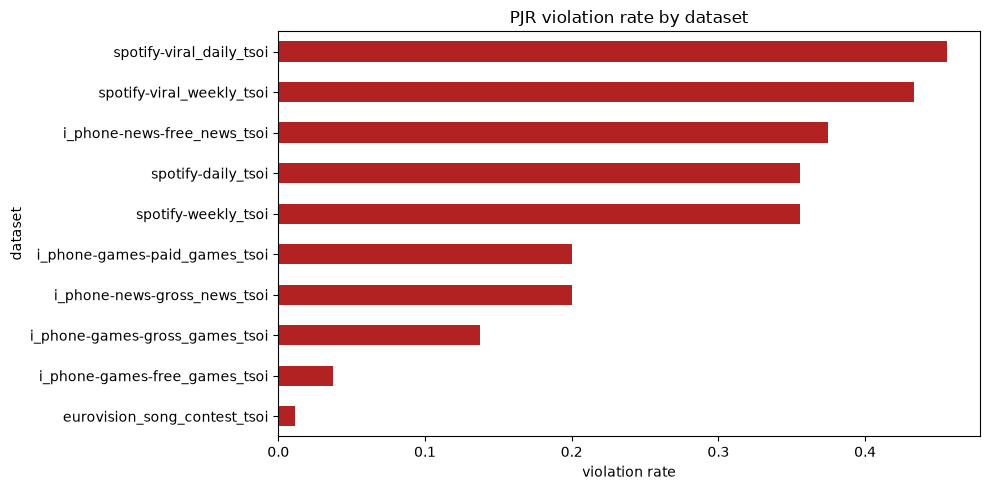

In [5]:
violation_rate_by_dataset = (1 - results_df.groupby("dataset")["satisfied"].mean()).sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 5))
violation_rate_by_dataset.plot(kind="barh", ax=ax, color="firebrick")
ax.set_xlabel("violation rate")
ax.set_title("PJR violation rate by dataset")
ax.invert_yaxis()
fig.tight_layout()

violation_rate_by_dataset

## Violation rate by n and by T (all datasets combined)

Same shape of analysis as the synthetic grid notebook: does violation
rate scale with voter count or round count, pooling across every real
dataset?

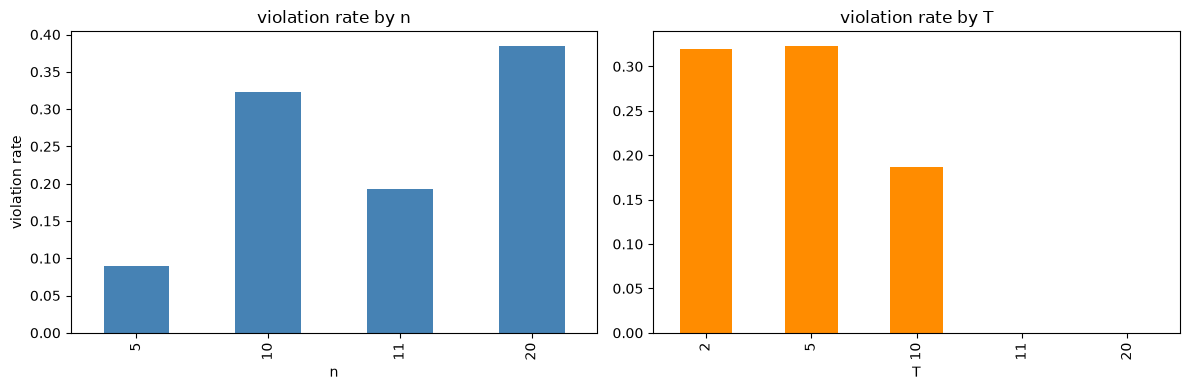

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(1 - results_df.groupby("n")["satisfied"].mean()).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("violation rate by n")
axes[0].set_ylabel("violation rate")

(1 - results_df.groupby("T")["satisfied"].mean()).plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("violation rate by T")
fig.tight_layout()

## Violation rate heatmap: n x T (all datasets combined)

The same (n, T) heatmap as the synthetic grid notebook
(`eda/pjr_eda.ipynb`), pooling across every real dataset -- directly
comparable to that notebook's heatmap to check whether the same
configuration is worst in both.

T,2,5,10,11,20
n,,,,,
5,0.18,0.00,NaN,NaN,NaN
10,0.46,0.51,0.00,NaN,NaN
11,0.24,0.34,NaN,0.0,NaN
20,0.40,0.58,0.56,NaN,0.0


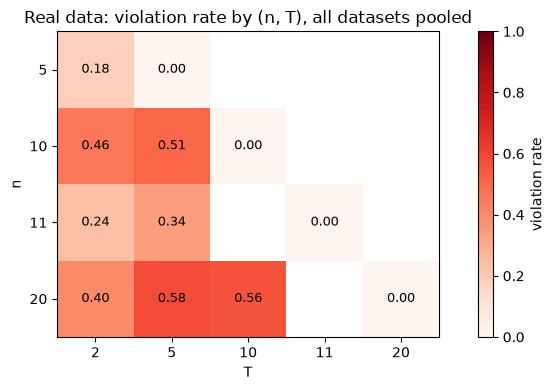

In [7]:
global_pivot = 1 - results_df.pivot_table(
    index="n", columns="T", values="satisfied", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(global_pivot.values, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(len(global_pivot.columns)), labels=global_pivot.columns)
ax.set_yticks(range(len(global_pivot.index)), labels=global_pivot.index)
for i in range(len(global_pivot.index)):
    for j in range(len(global_pivot.columns)):
        value = global_pivot.values[i, j]
        if not pd.isna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9)
ax.set_xlabel("T")
ax.set_ylabel("n")
ax.set_title("Real data: violation rate by (n, T), all datasets pooled")
fig.colorbar(im, ax=ax, label="violation rate")
fig.tight_layout()

global_pivot

## Is the worst configuration the same as in the synthetic grid?

The synthetic grid's worst configurations were all at **n=20, T=2** (see
`eda/pjr_eda.ipynb`'s "worst configurations" table -- the top two
entries were both `n=20, T=2`). Checking directly whether that holds for
real data too, rather than assuming it does.

In [8]:
stacked = global_pivot.stack()
worst_n, worst_t = stacked.idxmax()
worst_rate = stacked.max()

synthetic_worst_n, synthetic_worst_t = 20, 2
synthetic_worst_rate = global_pivot.loc[synthetic_worst_n, synthetic_worst_t]

print(
    f"Real data's worst pooled (n, T): n={worst_n}, T={worst_t} -> {worst_rate:.1%} violation rate"
)
print(
    f"Synthetic's worst (n, T) was n={synthetic_worst_n}, T={synthetic_worst_t} -- "
    f"on real data that same cell is {synthetic_worst_rate:.1%}"
)
if (worst_n, worst_t) == (synthetic_worst_n, synthetic_worst_t):
    print("=> Same configuration is worst in both.")
else:
    print(
        f"=> NOT the same configuration: real data's worst is n={worst_n}, T={worst_t}, "
        f"not n={synthetic_worst_n}, T={synthetic_worst_t} "
        "(though the latter is still notably bad)."
    )

Real data's worst pooled (n, T): n=20, T=5 -> 58.0% violation rate
Synthetic's worst (n, T) was n=20, T=2 -- on real data that same cell is 40.0%
=> NOT the same configuration: real data's worst is n=20, T=5, not n=20, T=2 (though the latter is still notably bad).


## Does T = n (the largest T tier for that n) behave differently?

Every configuration's T grid tops out at T = n itself (e.g. n=20's grid
is T in {2, 5, 10, 20}). Worth checking directly, since if it holds up
it's a clean result: enough rounds resolves PJR robustly, even on messy
real-world preference data.

In [9]:
at_max_t = results_df[results_df["T"] == results_df["n"]]
below_max_t = results_df[results_df["T"] < results_df["n"]]

at_max_t_rate = 1 - at_max_t["satisfied"].mean()
below_max_t_rate = 1 - below_max_t["satisfied"].mean()
print(f"T == n:  {len(at_max_t)} runs, violation rate = {at_max_t_rate:.1%}")
print(f"T < n:   {len(below_max_t)} runs, violation rate = {below_max_t_rate:.1%}")

T == n:  300 runs, violation rate = 0.0%
T < n:   550 runs, violation rate = 40.2%


## Are the designated "first rounds" runs any different?

Each configuration's run 0 always uses the dataset's actual first T
rounds (`is_first_rounds=True`); every other run uses a random
contiguous window. If there's something structurally different about
the start of these real time series (e.g. a "settling in" period),
it should show up here as a rate gap.

In [10]:
first_rounds_comparison = 1 - results_df.groupby("is_first_rounds")["satisfied"].mean()
first_rounds_comparison.index = first_rounds_comparison.index.map(
    {True: "first rounds (run 0)", False: "random window"}
)
first_rounds_comparison

is_first_rounds
random window           0.260131
first rounds (run 0)    0.258824
Name: satisfied, dtype: float64

## Distribution of violations per run

Same as the synthetic notebook, but note the y-axis: real data's
violation counts are far more skewed than synthetic (see below), so
this is shown on a log scale for the violating runs.

count       221.000000
mean       2730.628959
std       12690.059884
min           1.000000
25%           1.000000
50%          11.000000
75%          93.000000
max      106762.000000
Name: num_violations, dtype: float64

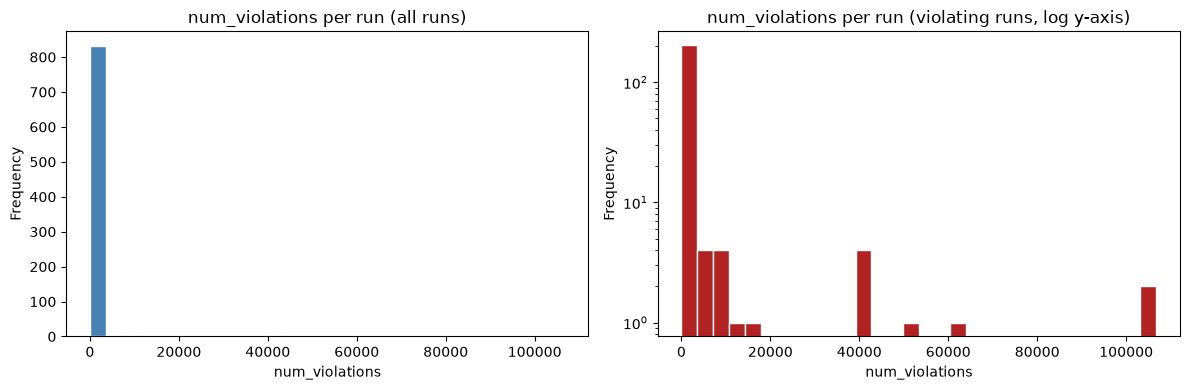

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df["num_violations"].plot(
    kind="hist", bins=30, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("num_violations per run (all runs)")
axes[0].set_xlabel("num_violations")

violating = results_df.loc[~results_df["satisfied"]]
violating["num_violations"].plot(
    kind="hist", bins=30, ax=axes[1], color="firebrick", edgecolor="white", log=True
)
axes[1].set_title("num_violations per run (violating runs, log y-axis)")
axes[1].set_xlabel("num_violations")
fig.tight_layout()

violating["num_violations"].describe()

## Worst-case severity

`worst_gap` / `worst_group_size` for each run's single worst-violated
group.

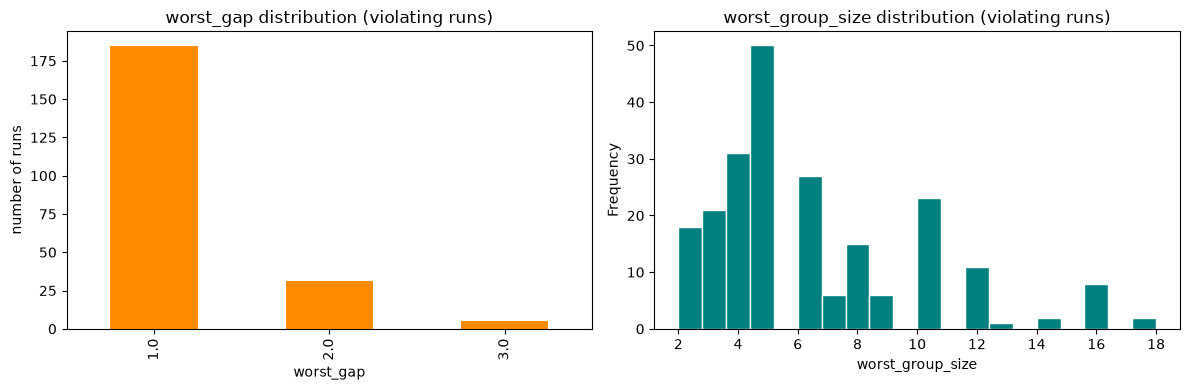

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

violating["worst_gap"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("worst_gap distribution (violating runs)")
axes[0].set_xlabel("worst_gap")
axes[0].set_ylabel("number of runs")

violating["worst_group_size"].plot(
    kind="hist", bins=20, ax=axes[1], color="teal", edgecolor="white"
)
axes[1].set_title("worst_group_size distribution (violating runs)")
axes[1].set_xlabel("worst_group_size")
fig.tight_layout()

## Per-dataset summary table

One row per dataset: how many runs, overall violation rate, average
violation count, and the single worst gap seen anywhere in that
dataset.

In [13]:
dataset_summary = results_df.groupby("dataset").agg(
    runs=("run", "count"),
    violation_rate=("satisfied", lambda s: 1 - s.mean()),
    avg_num_violations=("num_violations", "mean"),
    max_num_violations=("num_violations", "max"),
    max_worst_gap=("worst_gap", "max"),
).sort_values("violation_rate", ascending=False)

dataset_summary

,runs,violation_rate,avg_num_violations,max_num_violations,max_worst_gap
dataset,,,,,
spotify-viral_daily_tsoi,90,0.455556,1009.733333,41830,3.0
spotify-viral_weekly_tsoi,90,0.433333,4372.922222,106762,3.0
i_phone-news-free_news_tsoi,80,0.375000,9.350000,176,2.0
spotify-daily_tsoi,90,0.355556,195.088889,13292,3.0
spotify-weekly_tsoi,90,0.355556,1110.255556,52528,3.0
i_phone-games-paid_games_tsoi,80,0.200000,4.112500,130,2.0
i_phone-news-gross_news_tsoi,80,0.200000,3.900000,93,2.0
i_phone-games-gross_games_tsoi,80,0.137500,1.725000,37,1.0
i_phone-games-free_games_tsoi,80,0.037500,0.125000,7,1.0


## Per-dataset breakdown: violation rate by (n, T)

One heatmap per dataset (same color scale, 0 to 1, as the global heatmap
above), so each dataset's own (n, T) pattern is visible individually --
and comparable to the others at a glance -- rather than only pooled into
the global charts above.

Text(0.5, 0.98, 'Violation rate by (n, T), per dataset')

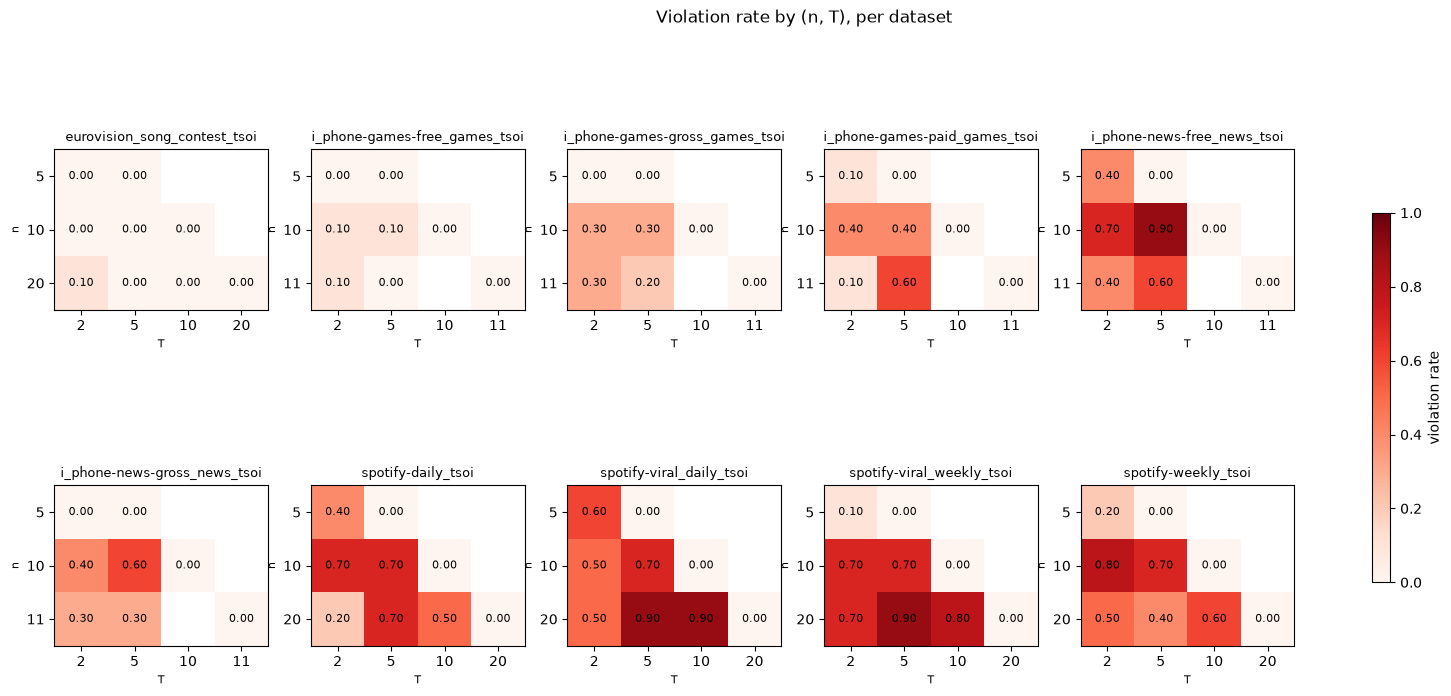

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, name in zip(axes.flat, dataset_names, strict=True):
    subset = results_df[results_df["dataset"] == name]
    pivot = 1 - subset.pivot_table(index="n", columns="T", values="satisfied", aggfunc="mean")

    im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)), labels=pivot.columns)
    ax.set_yticks(range(len(pivot.index)), labels=pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.values[i, j]
            if not pd.isna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("T", fontsize=8)
    ax.set_ylabel("n", fontsize=8)

fig.colorbar(im, ax=axes, label="violation rate", shrink=0.6)
fig.suptitle("Violation rate by (n, T), per dataset")

## Worst single run per dataset

The single most-violating run in each dataset, for a concrete anchor
into what "worst case" actually looks like per dataset.

In [15]:
worst_columns = [
    "run",
    "n",
    "T",
    "round_start",
    "is_first_rounds",
    "num_violations",
    "worst_gap",
    "worst_group_size",
]
worst_per_dataset = results_df.loc[
    results_df.groupby("dataset")["num_violations"].idxmax()
].set_index("dataset")[worst_columns]
worst_per_dataset.sort_values("num_violations", ascending=False)

,run,n,T,round_start,is_first_rounds,num_violations,worst_gap,worst_group_size
dataset,,,,,,,,
spotify-viral_weekly_tsoi,run_85,20,2,112,False,106762,1.0,10.0
spotify-weekly_tsoi,run_78,20,5,127,False,52528,3.0,12.0
spotify-viral_daily_tsoi,run_76,20,5,1012,False,41830,3.0,13.0
spotify-daily_tsoi,run_63,20,10,1017,False,13292,3.0,6.0
i_phone-news-free_news_tsoi,run_30,10,5,0,True,176,2.0,4.0
i_phone-games-paid_games_tsoi,run_75,11,2,26,False,130,1.0,6.0
i_phone-news-gross_news_tsoi,run_41,10,2,47,False,93,1.0,5.0
i_phone-games-gross_games_tsoi,run_78,11,2,4,False,37,1.0,6.0
eurovision_song_contest_tsoi,run_88,20,2,31,False,12,1.0,10.0


## Outliers and other interesting findings

Computed from the data above, not assumed beforehand:

In [16]:
overall_worst = results_df.loc[results_df["num_violations"].idxmax()]
best_dataset = violation_rate_by_dataset.idxmin()
worst_dataset = violation_rate_by_dataset.idxmax()
best_rate = violation_rate_by_dataset[best_dataset]
worst_rate = violation_rate_by_dataset[worst_dataset]
spread = worst_rate / max(best_rate, 1e-9)

print("Dataset-to-dataset spread is the dominant effect:")
print(
    f"  {worst_dataset}: {worst_rate:.1%} violation rate vs. {best_dataset}: "
    f"{best_rate:.1%} -- a {spread:.0f}x spread."
)
print()
print("T == n (the largest T tier) satisfied PJR in every single run, across every")
print("dataset and every n -- a clean, fully consistent result (see the T==n check above).")
print()
print(
    f"Violation counts among violating runs are extremely right-skewed: median "
    f"{violating['num_violations'].median():.0f}, mean {violating['num_violations'].mean():.0f}, "
    f"max {violating['num_violations'].max():.0f}."
)

total_groups = 2 ** int(overall_worst["n"]) - 1
worst_fraction = overall_worst["num_violations"] / total_groups
print(
    f"The single worst run overall is {overall_worst['dataset']} run {overall_worst['run']} "
    f"(n={overall_worst['n']}, T={overall_worst['T']}): {overall_worst['num_violations']:.0f} "
    f"violating groups (~{worst_fraction:.1%} of all {total_groups:,} possible groups), yet its "
    f"single worst gap was only {overall_worst['worst_gap']:.0f} -- a large number of "
    f"*barely*-violated small groups, not a few severely-underserved ones."
)

Dataset-to-dataset spread is the dominant effect:
  spotify-viral_daily_tsoi: 45.6% violation rate vs. eurovision_song_contest_tsoi: 1.1% -- a 41x spread.

T == n (the largest T tier) satisfied PJR in every single run, across every
dataset and every n -- a clean, fully consistent result (see the T==n check above).

Violation counts among violating runs are extremely right-skewed: median 11, mean 2731, max 106762.
The single worst run overall is spotify-viral_weekly_tsoi run run_85 (n=20, T=2): 106762 violating groups (~10.2% of all 1,048,575 possible groups), yet its single worst gap was only 1 -- a large number of *barely*-violated small groups, not a few severely-underserved ones.


## Next steps

- The (n, T) heatmap comparison above shows real data's worst cell
  doesn't match synthetic's -- worth digging into *why* (n=20, T=5) is
  uniquely bad for real data specifically, rather than just noting that
  it differs.
- Investigate why dataset identity dominates so strongly: is it
  candidate pool size, approval set sparsity, or genuine structural
  differences in how cohesive voter blocs are within each dataset (see
  `eda/spotify_eda.ipynb` for one such investigation, focused on
  candidate/approval characteristics)?
- The T == n result is clean enough to be worth stating as a finding on
  its own, but is based on real_aaai_grid_experiment's specific T grid
  (a handful of values per n) -- worth checking whether violation rate
  keeps falling smoothly as T grows past n, or whether n itself happens
  to be a special threshold for these datasets.